# Magnetic Phase Sample

Preview the magnetic-like phase objects and how their optical path length modifications combine.


## Setup

Enable double precision for JAX, pull in the Gaussian Taylor components, and configure interactive plotting.


In [73]:
import os

os.environ["JAX_ENABLE_X64"] = "1"

%matplotlib widget

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import Detector
from temgym_core.gaussian_taylor import magnetic_phase_sample


## Build Magnetic Samples

Lay out three soft-edged phase objects with increasing footprints and subtle internal texture.


In [83]:
window_width = 2e-6  # metres
Nx = Ny = 512
pixel_size = window_width / Nx

output_grid = Detector(
    z=0.0,
    pixel_size=(pixel_size, pixel_size),
    shape=(Ny, Nx),
)

sample_chain = (
    magnetic_phase_sample(
        z=output_grid.z,
        strength=0.8e-12,
        width=0.2e-6,
        height=0.2e-6,
        center=(-0.01e-6, -0.01e-6),
        theta=-0.15,
        modulation_strength=0.1,
        skew_strength=0.01,
        radial_strength=0,
        edge_sharpness=1e8,
    ),
)

def component_phase_mask(component):
    mask_flat = jax.vmap(component.opl_shift)(output_grid.coords)
    return mask_flat.reshape(output_grid.shape)

phase_masks = [component_phase_mask(component) for component in sample_chain]
combined_phase = jnp.sum(jnp.stack(phase_masks, axis=0), axis=0)

extent = output_grid.extent
extent_um = tuple(float(val) * 1e6 for val in extent)
x_coords_um, y_coords_um = output_grid.coords_1d
x_coords_um = np.asarray(x_coords_um) * 1e6
y_coords_um = np.asarray(y_coords_um) * 1e6

center_row = Ny // 2
line_profiles = [np.asarray(mask[center_row, :]) for mask in phase_masks]
line_combined = np.asarray(combined_phase[center_row, :])


## Visualise Phase Structure

Plot each element and the combined phase shift in microns, plus the horizontal cross-section through the centre.


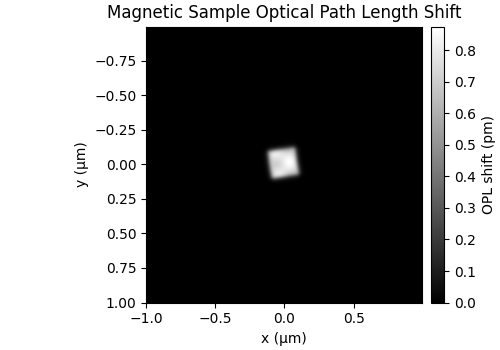

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5), constrained_layout=True)
titles = ['Sample 1']
data = [
    np.asarray(phase_masks[0]),
]

title = 'Magnetic Sample Optical Path Length Shift'
arr = np.asarray(combined_phase)
im = ax.imshow(
    arr * 1e12,
    extent=extent_um,
    origin='lower',
    cmap='grey',
)
ax.set_title(title)
ax.set_xlabel('x (\u00b5m)')
ax.set_ylabel('y (\u00b5m)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='OPL shift (pm)')

plt.show()


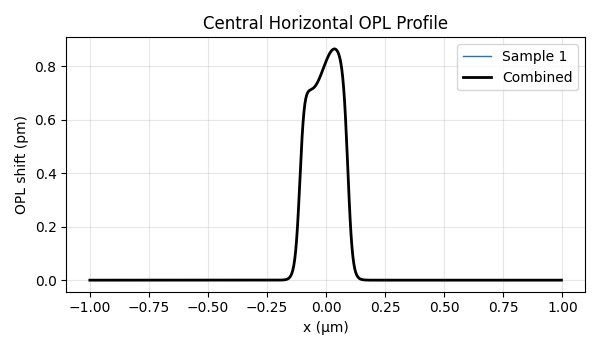

In [86]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for arr, label in zip(line_profiles, ['Sample 1', 'Sample 2', 'Sample 3']):
    ax.plot(x_coords_um, arr * 1e12, label=label, linewidth=1.0)
ax.plot(x_coords_um, line_combined * 1e12, label='Combined', linewidth=2.0, color='black')
ax.set_xlabel('x (\u00b5m)')
ax.set_ylabel('OPL shift (pm)')
ax.set_title('Central Horizontal OPL Profile')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
